1. Chọn 1 bộ dữ liệu thô trên kaggle (có đầy đủ các thuộc tính norminal, ordinal, interval, ratio)
2. Xác định dữ liệu có chứa nhiễu hay không? (Sử dụng một trong các phương pháp trong slide 3)
3. Kiểm tra dữ liệu xem có chứa các thành phần: missing value, duplicate value, inconsistent value hay không?
4. Áp dụng 1 trong các phương pháp tiền xử lý để xử lý dữ liệu ở câu 3.
5. Áp dụng 1 trong các phương pháp khử nhiễu để xử lý dữ liệu ở câu 4.
6. Lựa chọn 1 trong các phương pháp giảm chiều như PCA, euclid, fourier để giảm 20-30% số chiều của dữ liệu gốc.
7. Biểu diễn phân bố dữ liệu của các thuộc tính sau khi giảm chiều.
8. Xác định các cặp thuộc tính có tương quan (theo X^2, Pearson, Spearman, covariance). Và chọn ra 1 cặp thuộc tính có tương quan cao nhất để đưa ra lý giải về mối tương quan này.

# Lab 2 - Tiền xử lý dữ liệu và phân tích tương quan

> Bộ dữ liệu chọn từ Kaggle: **Hotel Booking Demand**

> Link: https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand

## 1. Chọn bộ dữ liệu thô trên Kaggle và xác định kiểu thuộc tính

**Bộ dữ liệu:** Hotel Booking Demand (`hotel_bookings.csv`).

**Một số thuộc tính đại diện theo thang đo:**

- **Nominal:** `hotel`, `meal`, `country`, `market_segment`, `reserved_room_type`
- **Ordinal:** `arrival_date_month` (tháng có thứ tự thời gian), `deposit_type` (có thể quy ước thứ tự mức ràng buộc)
- **Interval:** `arrival_date_year` (mốc năm, chênh lệch có ý nghĩa)
- **Ratio:** `lead_time`, `adr`, `stays_in_week_nights`, `stays_in_weekend_nights`, `adults`, `children`, `babies`

> Lưu ý: Trong thực hành data mining, một số biến có thể được mô hình hóa linh hoạt tùy bài toán. Ở đây ta dùng quy ước phù hợp với đề lab.

In [1]:
# Cài thư viện nếu môi trường chưa có (bỏ comment để chạy khi cần)
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

In [2]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import sparse
from scipy.stats import zscore, chi2_contingency
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 100)

## Đọc dữ liệu thô

Cell này đọc file `hotel_bookings.csv` và hiển thị kích thước, kiểu dữ liệu ban đầu.

In [3]:
data_path = Path("hotel_bookings.csv")
if not data_path.exists():
    raise FileNotFoundError(
        "Không tìm thấy hotel_bookings.csv. Hãy tải từ Kaggle và đặt cùng thư mục với notebook."
    )

df_raw = pd.read_csv(data_path)
print(f"Kích thước dữ liệu gốc: {df_raw.shape}")
display(df_raw.head())
display(df_raw.dtypes.to_frame("dtype").T)

Kích thước dữ liệu gốc: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Corporate,Corporate,0,0,0,A,A,0,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,0.0,0,BB,GBR,Online TA,TA/TO,0,0,0,A,A,0,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
dtype,str,int64,int64,int64,str,int64,int64,int64,int64,int64,float64,int64,str,str,str,str,int64,int64,int64,str,str,int64,str,float64,float64,int64,str,float64,int64,int64,str,str


## 2. Xác định dữ liệu có chứa nhiễu hay không (phương pháp Z-score)

Ta kiểm tra các biến số bằng Z-score, xem các điểm có $|z| > 3$ là ngoại lai (nhiễu).

In [4]:
numeric_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
z_df = df_raw[numeric_cols].copy()
z_df = z_df.fillna(z_df.median(numeric_only=True))

z_values_raw = zscore(z_df, nan_policy="omit")
z_values = np.abs(np.asarray(z_values_raw, dtype=float))
z_values = np.nan_to_num(z_values, nan=0.0)
outlier_mask = (z_values > 3).any(axis=1)

n_outliers = int(outlier_mask.sum())
pct_outliers = n_outliers / len(df_raw) * 100
print(f"Số dòng bị xem là nhiễu theo Z-score: {n_outliers} ({pct_outliers:.2f}%)")

Số dòng bị xem là nhiễu theo Z-score: 27126 (22.72%)


## 3. Kiểm tra missing value, duplicate value, inconsistent value

- **Missing value**: đếm số lượng giá trị khuyết theo cột.
- **Duplicate value**: đếm số dòng trùng lặp hoàn toàn.
- **Inconsistent value**: kiểm tra một số cột danh mục theo tập giá trị hợp lệ (ví dụ tháng, loại khách sạn).

In [5]:
missing_summary = df_raw.isna().sum().sort_values(ascending=False)
duplicate_count = int(df_raw.duplicated().sum())

valid_months = {
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
}
invalid_month_count = 0
if "arrival_date_month" in df_raw.columns:
    invalid_month_count = int((~df_raw["arrival_date_month"].isin(valid_months)).sum())

print("Tổng số missing values:", int(missing_summary.sum()))
print("Số dòng duplicate:", duplicate_count)
print("Số giá trị tháng không hợp lệ:", invalid_month_count)
display(missing_summary[missing_summary > 0].to_frame("missing_count").head(20))

Tổng số missing values: 129425
Số dòng duplicate: 31994
Số giá trị tháng không hợp lệ: 0


,missing_count
company,112593
agent,16340
country,488
children,4


## 4. Tiền xử lý dữ liệu

Phương pháp tiền xử lý áp dụng:

- Xóa dòng trùng lặp.
- Chuẩn hóa giá trị chuỗi (strip khoảng trắng).
- Điền missing: trung vị cho biến số, mode cho biến phân loại.
- Loại các dòng có tháng không hợp lệ (nếu có).

In [6]:
df_clean = df_raw.copy()

for c in df_clean.select_dtypes(include="object").columns:
    df_clean[c] = df_clean[c].astype(str).str.strip()
    df_clean[c] = df_clean[c].replace({"nan": np.nan})

df_clean = df_clean.drop_duplicates().copy()

num_cols = df_clean.select_dtypes(include=[np.number]).columns
cat_cols = df_clean.select_dtypes(exclude=[np.number]).columns

df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median(numeric_only=True))
for c in cat_cols:
    if df_clean[c].isna().any():
        df_clean[c] = df_clean[c].fillna(df_clean[c].mode().iloc[0])

if "arrival_date_month" in df_clean.columns:
    df_clean = df_clean[df_clean["arrival_date_month"].isin(valid_months)].copy()

print(f"Kích thước sau tiền xử lý: {df_clean.shape}")
print("Missing còn lại:", int(df_clean.isna().sum().sum()))
print("Duplicate còn lại:", int(df_clean.duplicated().sum()))

Kích thước sau tiền xử lý: (87396, 32)
Missing còn lại: 0
Duplicate còn lại: 19


## 5. Khử nhiễu dữ liệu

Phương pháp khử nhiễu áp dụng: **Winsorization theo IQR** cho các biến số.

Ý tưởng: chặn giá trị vượt ngoài đoạn $[Q1 - 1.5\times IQR,\ Q3 + 1.5\times IQR]$.

In [7]:
df_denoised = df_clean.copy()
numeric_cols_clean = df_denoised.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols_clean:
    q1 = df_denoised[col].quantile(0.25)
    q3 = df_denoised[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df_denoised[col] = df_denoised[col].clip(lower=lower, upper=upper)

print(f"Kích thước sau khử nhiễu: {df_denoised.shape}")

Kích thước sau khử nhiễu: (87396, 32)


## 6. Giảm chiều bằng PCA (giảm 30% số chiều gốc)

- Mã hóa One-Hot cho biến phân loại.
- Chuẩn hóa biến số.
- Dùng PCA để giữ lại **70% số chiều** (tức giảm khoảng 30%).

In [8]:
target_col = "is_canceled" if "is_canceled" in df_denoised.columns else None
X = df_denoised.drop(columns=[target_col]) if target_col else df_denoised.copy()

num_features = X.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ]
)

X_processed = preprocessor.fit_transform(X)
n_original_dims = X_processed.shape[1]
n_components = max(2, int(np.ceil(n_original_dims * 0.70)))

pca = PCA(n_components=n_components, random_state=42)
if sparse.issparse(X_processed):
    X_dense = sparse.csr_matrix(X_processed).toarray()
else:
    X_dense = np.asarray(X_processed)
X_pca = pca.fit_transform(X_dense)

pca_cols = [f"PC{i+1}" for i in range(X_pca.shape[1])]
df_pca = pd.DataFrame(X_pca, columns=pca_cols, index=df_denoised.index)
if target_col:
    df_pca[target_col] = df_denoised[target_col].values

reduction_pct = (1 - X_pca.shape[1] / n_original_dims) * 100
print(f"Số chiều trước PCA: {n_original_dims}")
print(f"Số chiều sau PCA: {X_pca.shape[1]}")
print(f"Tỷ lệ giảm chiều: {reduction_pct:.2f}%")
print(f"Tổng phương sai giải thích: {pca.explained_variance_ratio_.sum():.4f}")

Số chiều trước PCA: 1186
Số chiều sau PCA: 831
Tỷ lệ giảm chiều: 29.93%
Tổng phương sai giải thích: 0.9962


## 7. Biểu diễn phân bố dữ liệu sau giảm chiều

Ta trực quan phân bố của các thành phần chính đầu tiên (`PC1`, `PC2`, `PC3`) bằng histogram và scatter plot.

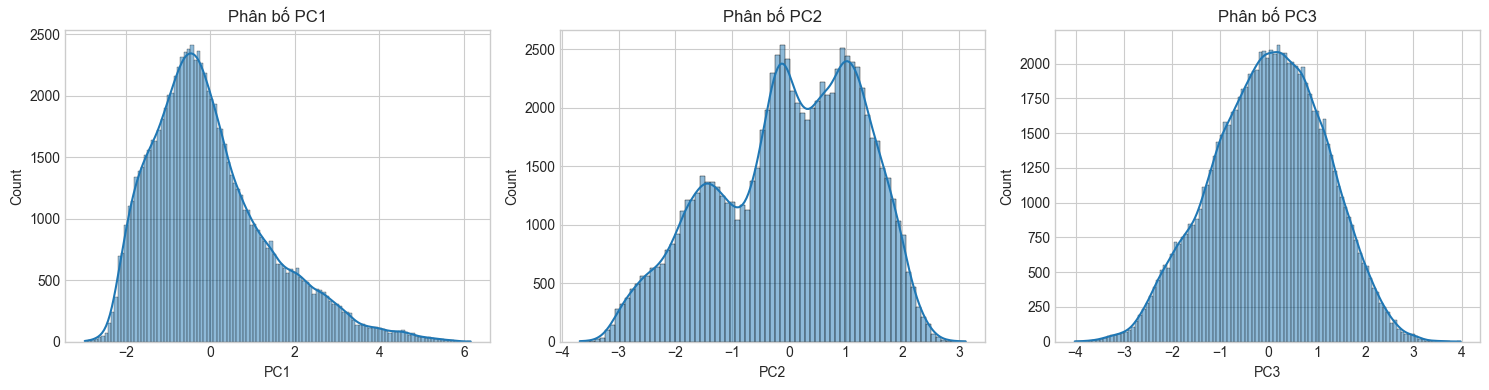

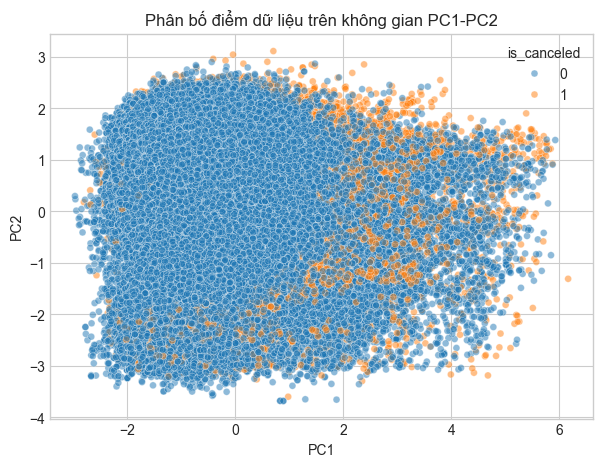

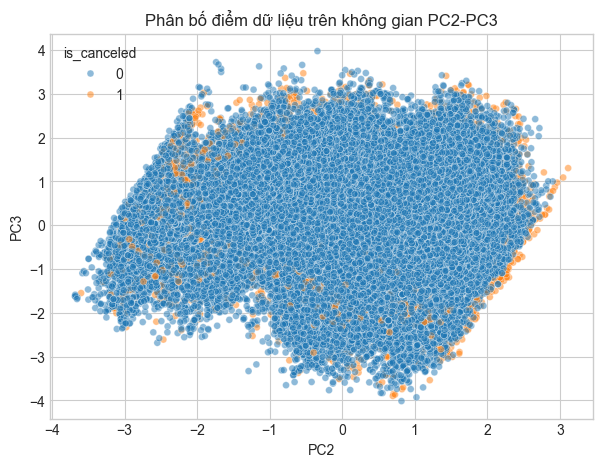

In [9]:
plot_cols = [c for c in ["PC1", "PC2", "PC3"] if c in df_pca.columns]

fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 4))
if len(plot_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, plot_cols):
    sns.histplot(data=df_pca, x=col, kde=True, ax=ax, color="#1f77b4")
    ax.set_title(f"Phân bố {col}")

plt.tight_layout()
plt.show()

if {"PC1", "PC2"}.issubset(df_pca.columns):
    plt.figure(figsize=(7, 5))
    if target_col and target_col in df_pca.columns:
        sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue=target_col, alpha=0.5, s=25)
    else:
        sns.scatterplot(data=df_pca, x="PC1", y="PC2", alpha=0.5, s=25, color="#ff7f0e")
    plt.title("Phân bố điểm dữ liệu trên không gian PC1-PC2")
    plt.show()

if {"PC2", "PC3"}.issubset(df_pca.columns):
    plt.figure(figsize=(7, 5))
    if target_col and target_col in df_pca.columns:
        sns.scatterplot(data=df_pca, x="PC2", y="PC3", hue=target_col, alpha=0.5, s=25)
    else:
        sns.scatterplot(data=df_pca, x="PC2", y="PC3", alpha=0.5, s=25, color="#ff7f0e")
    plt.title("Phân bố điểm dữ liệu trên không gian PC2-PC3")
    plt.show()

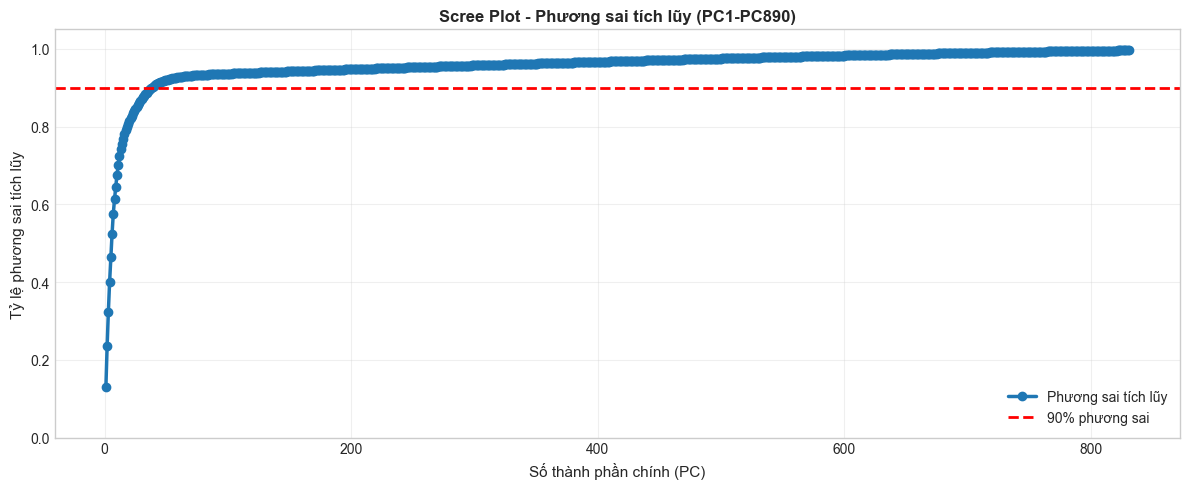


Thông tin Scree plot:
- Tổng số PC: 831
- PC được hiển thị: 831
  PC1: 0.1297 (12.97%) | Tích lũy: 0.1297 (12.97%)
  PC2: 0.1053 (10.53%) | Tích lũy: 0.2350 (23.50%)
  PC3: 0.0882 (8.82%) | Tích lũy: 0.3233 (32.33%)
  PC4: 0.0762 (7.62%) | Tích lũy: 0.3994 (39.94%)
  PC5: 0.0650 (6.50%) | Tích lũy: 0.4644 (46.44%)
  PC6: 0.0592 (5.92%) | Tích lũy: 0.5236 (52.36%)
  PC7: 0.0525 (5.25%) | Tích lũy: 0.5761 (57.61%)
  PC8: 0.0373 (3.73%) | Tích lũy: 0.6134 (61.34%)
  PC9: 0.0318 (3.18%) | Tích lũy: 0.6452 (64.52%)
  PC10: 0.0313 (3.13%) | Tích lũy: 0.6765 (67.65%)


In [10]:
# Scree plot
cumsum_var = np.cumsum(pca.explained_variance_ratio_)
individual_var = pca.explained_variance_ratio_
n_display = min(890, len(cumsum_var))

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(range(1, n_display + 1), cumsum_var[:n_display], marker="o", linestyle="-", 
        color="#1f77b4", linewidth=2.5, markersize=6, label="Phương sai tích lũy")
ax.axhline(y=0.90, color="r", linestyle="--", linewidth=2, label="90% phương sai")
ax.set_xlabel("Số thành phần chính (PC)", fontsize=11)
ax.set_ylabel("Tỷ lệ phương sai tích lũy", fontsize=11)
ax.set_title("Scree Plot - Phương sai tích lũy (PC1-PC890)", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3)
ax.set_ylim((0, 1.05))
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nThông tin Scree plot:")
print(f"- Tổng số PC: {len(cumsum_var)}")
print(f"- PC được hiển thị: {n_display}")
for i in range(min(10, len(individual_var))):
    print(f"  PC{i+1}: {individual_var[i]:.4f} ({individual_var[i]*100:.2f}%) | Tích lũy: {cumsum_var[i]:.4f} ({cumsum_var[i]*100:.2f}%)")

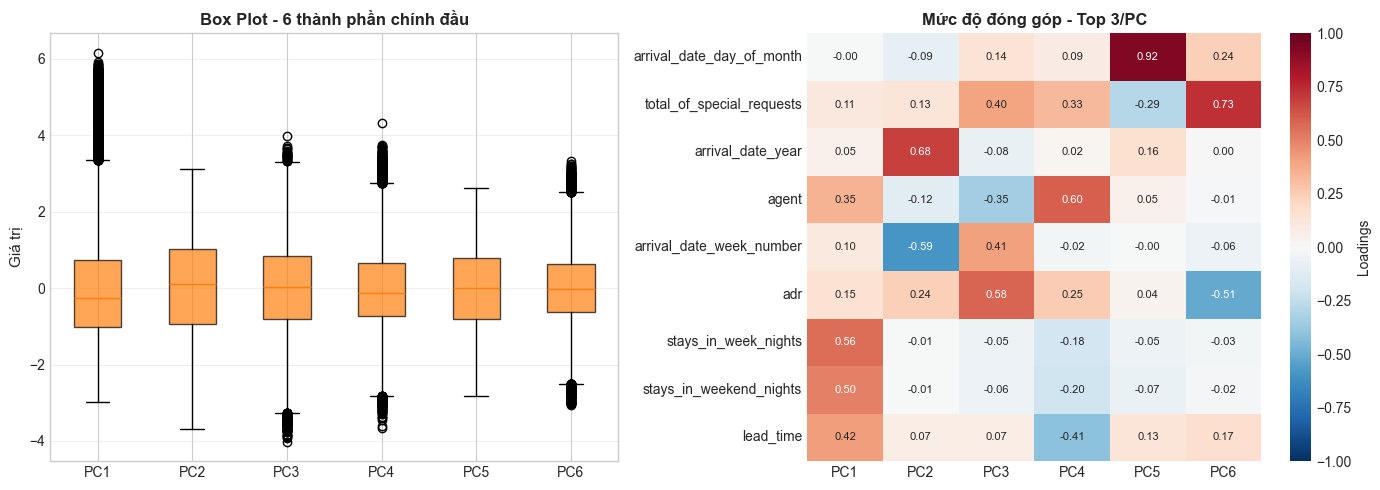


Tóm tắt 6 PC đầu:
  PC1: 0.1297 (12.97%)
  PC2: 0.1053 (10.53%)
  PC3: 0.0882 (8.82%)
  PC4: 0.0762 (7.62%)
  PC5: 0.0650 (6.50%)
  PC6: 0.0592 (5.92%)


In [11]:
# Box plot + Heatmap tối ưu - 6 PC đầu
n_pc_display = min(6, X_pca.shape[1])
plot_cols_optimized = [f"PC{i+1}" for i in range(n_pc_display)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot - Phân bố các PC chính
ax = axes[0]
box_data = [df_pca[col].values for col in plot_cols_optimized]
bp = ax.boxplot(box_data, labels=plot_cols_optimized, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#ff7f0e")
    patch.set_alpha(0.7)
ax.set_ylabel("Giá trị", fontsize=11)
ax.set_title(f"Box Plot - {n_pc_display} thành phần chính đầu", fontsize=12, fontweight="bold")
ax.grid(True, alpha=0.3, axis="y")

# Mức độ đóng góp (Loadings) - Top theo từng PC
ax = axes[1]
loadings = pca.components_[:n_pc_display].T

feature_names = preprocessor.get_feature_names_out()
feature_names = [name.split("__", 1)[-1] for name in feature_names]

top_k_per_pc = 3
selected_idx = []
for pc_idx in range(n_pc_display):
    pc_top_idx = np.argsort(np.abs(loadings[:, pc_idx]))[-top_k_per_pc:]
    selected_idx.extend(pc_top_idx.tolist())

# Loại trùng và sắp xếp theo mức đóng góp lớn nhất
top_idx = list(dict.fromkeys(selected_idx))
top_idx = sorted(top_idx, key=lambda i: np.abs(loadings[i, :n_pc_display]).max(), reverse=True)

loadings_top = loadings[top_idx]
top_feature_names = [feature_names[i] for i in top_idx]

sns.heatmap(loadings_top, annot=True, fmt=".2f", cmap="RdBu_r", center=0, ax=ax,
            cbar_kws={"label": "Loadings"}, vmin=-1, vmax=1,
            xticklabels=[f"PC{i+1}" for i in range(n_pc_display)],
            yticklabels=top_feature_names,
            annot_kws={"size": 8})
ax.set_title(f"Mức độ đóng góp - Top {top_k_per_pc}/PC", fontsize=12, fontweight="bold")

plt.tight_layout()
plt.show()

print(f"\nTóm tắt {n_pc_display} PC đầu:")
for i in range(n_pc_display):
    print(f"  PC{i+1}: {individual_var[i]:.4f} ({individual_var[i]*100:.2f}%)")

## 8. Phân tích tương quan theo X², Pearson, Spearman, Covariance

- Với biến số: tính **Pearson**, **Spearman**, **Covariance** cho mọi cặp biến.
- Với biến phân loại: tính **Chi-square (X²)** cho mọi cặp biến.
- Chọn cặp có độ tương quan cao nhất để lý giải.

,attr_1,attr_2,pearson,abs_pearson
37,arrival_date_year,arrival_date_week_number,-0.514228,0.514228
85,stays_in_weekend_nights,stays_in_week_nights,0.489918,0.489918
23,lead_time,stays_in_week_nights,0.352869,0.352869
22,lead_time,stays_in_weekend_nights,0.255157,0.255157
106,stays_in_week_nights,agent,0.199570,0.199570
0,is_canceled,lead_time,0.188645,0.188645
51,arrival_date_year,adr,0.186074,0.186074
93,stays_in_weekend_nights,agent,0.158205,0.158205
188,adr,total_of_special_requests,0.151771,0.151771
19,lead_time,arrival_date_year,0.140467,0.140467


,attr_1,attr_2,spearman,abs_spearman
37,arrival_date_year,arrival_date_week_number,-0.516153,0.516153
23,lead_time,stays_in_week_nights,0.418017,0.418017
85,stays_in_weekend_nights,stays_in_week_nights,0.327102,0.327102
22,lead_time,stays_in_weekend_nights,0.295543,0.295543
0,is_canceled,lead_time,0.226404,0.226404
51,arrival_date_year,adr,0.189236,0.189236
188,adr,total_of_special_requests,0.162269,0.162269
177,agent,adr,-0.147756,0.147756
16,is_canceled,adr,0.142841,0.142841
19,lead_time,arrival_date_year,0.137121,0.137121


,attr_1,attr_2,covariance,abs_covariance
31,lead_time,agent,636.311958,636.311958
34,lead_time,adr,152.045687,152.045687
20,lead_time,arrival_date_week_number,113.155018,113.155018
67,arrival_date_week_number,adr,70.371325,70.371325
177,agent,adr,-67.912050,67.912050
23,lead_time,stays_in_week_nights,51.690573,51.690573
106,stays_in_week_nights,agent,39.174626,39.174626
64,arrival_date_week_number,agent,28.502862,28.502862
22,lead_time,stays_in_weekend_nights,20.563022,20.563022
93,stays_in_weekend_nights,agent,17.084900,17.084900


,attr_1,attr_2,chi2,p_value
20,arrival_date_month,reservation_status_date,572225.344326,0.0
51,reserved_room_type,assigned_room_type,475815.561335,0.0
37,country,reservation_status_date,194425.845710,0.0
38,market_segment,distribution_channel,179090.406283,0.0
44,market_segment,reservation_status_date,28208.483643,0.0
42,market_segment,customer_type,28050.290643,0.0
62,deposit_type,reservation_status_date,20929.127343,0.0
64,customer_type,reservation_status_date,19615.759177,0.0
30,country,market_segment,15750.661032,0.0
29,meal,reservation_status_date,14025.356036,0.0


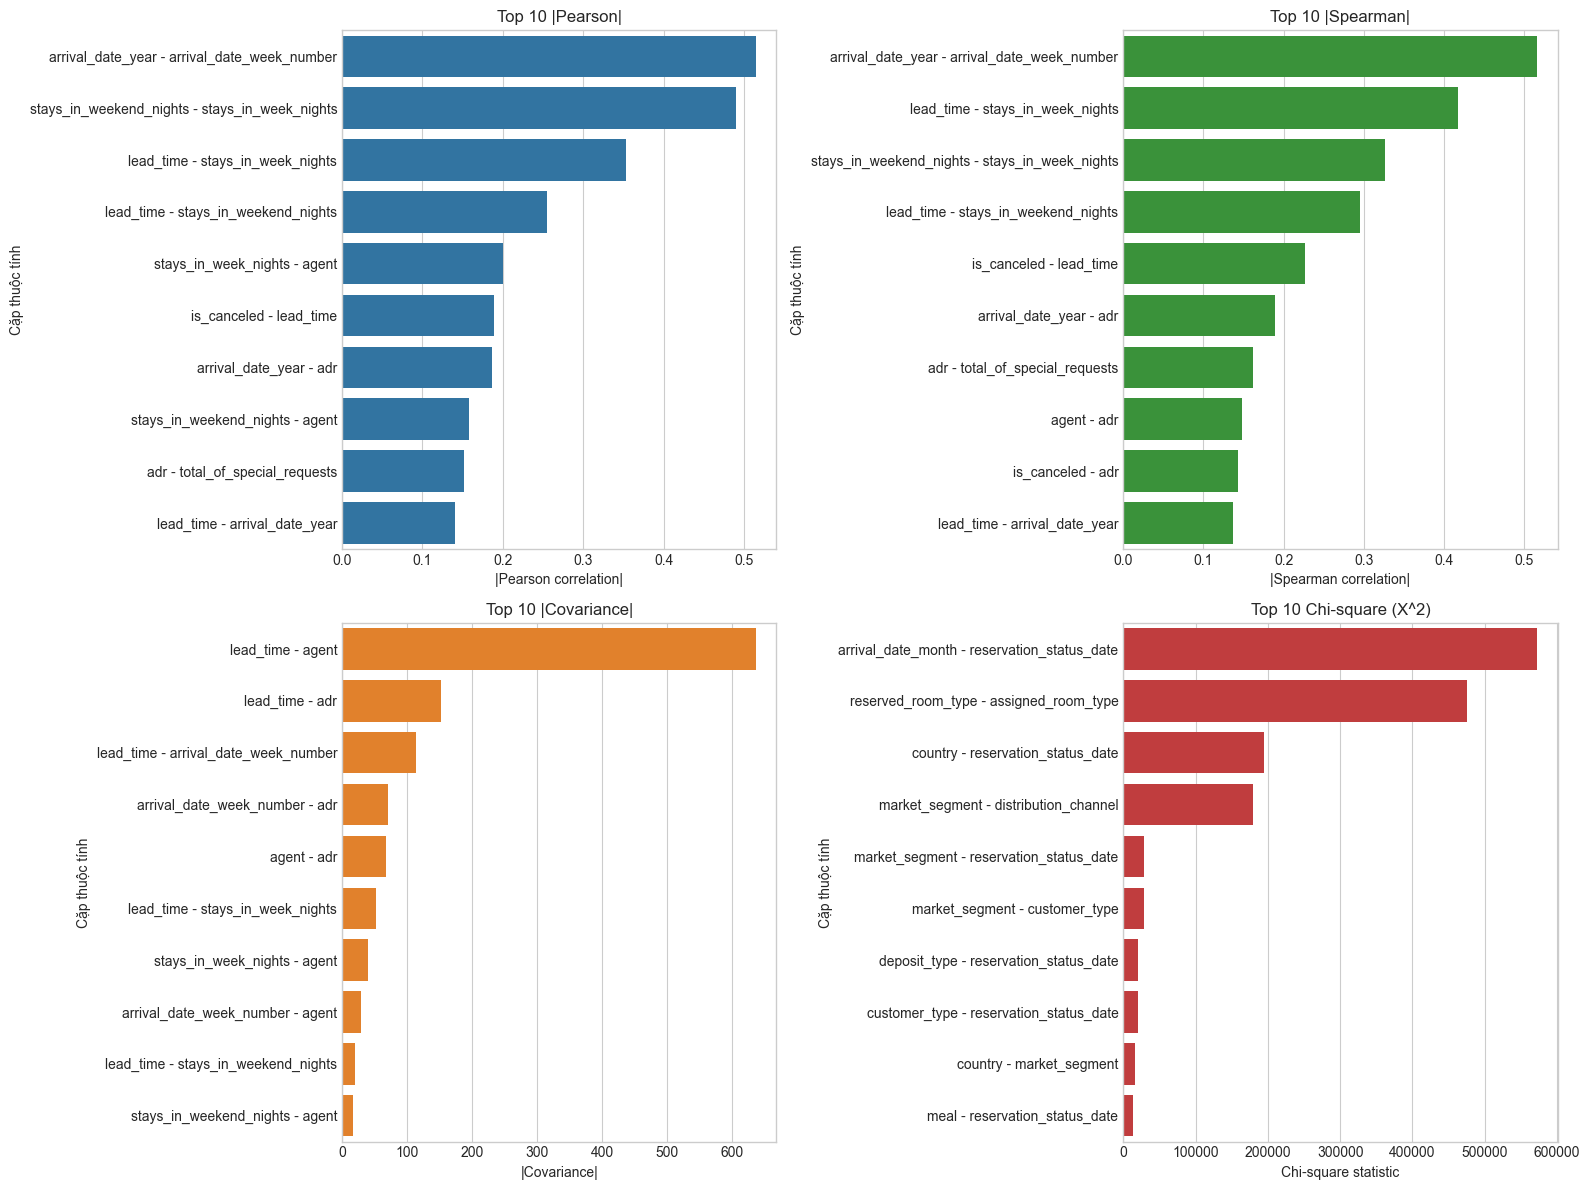

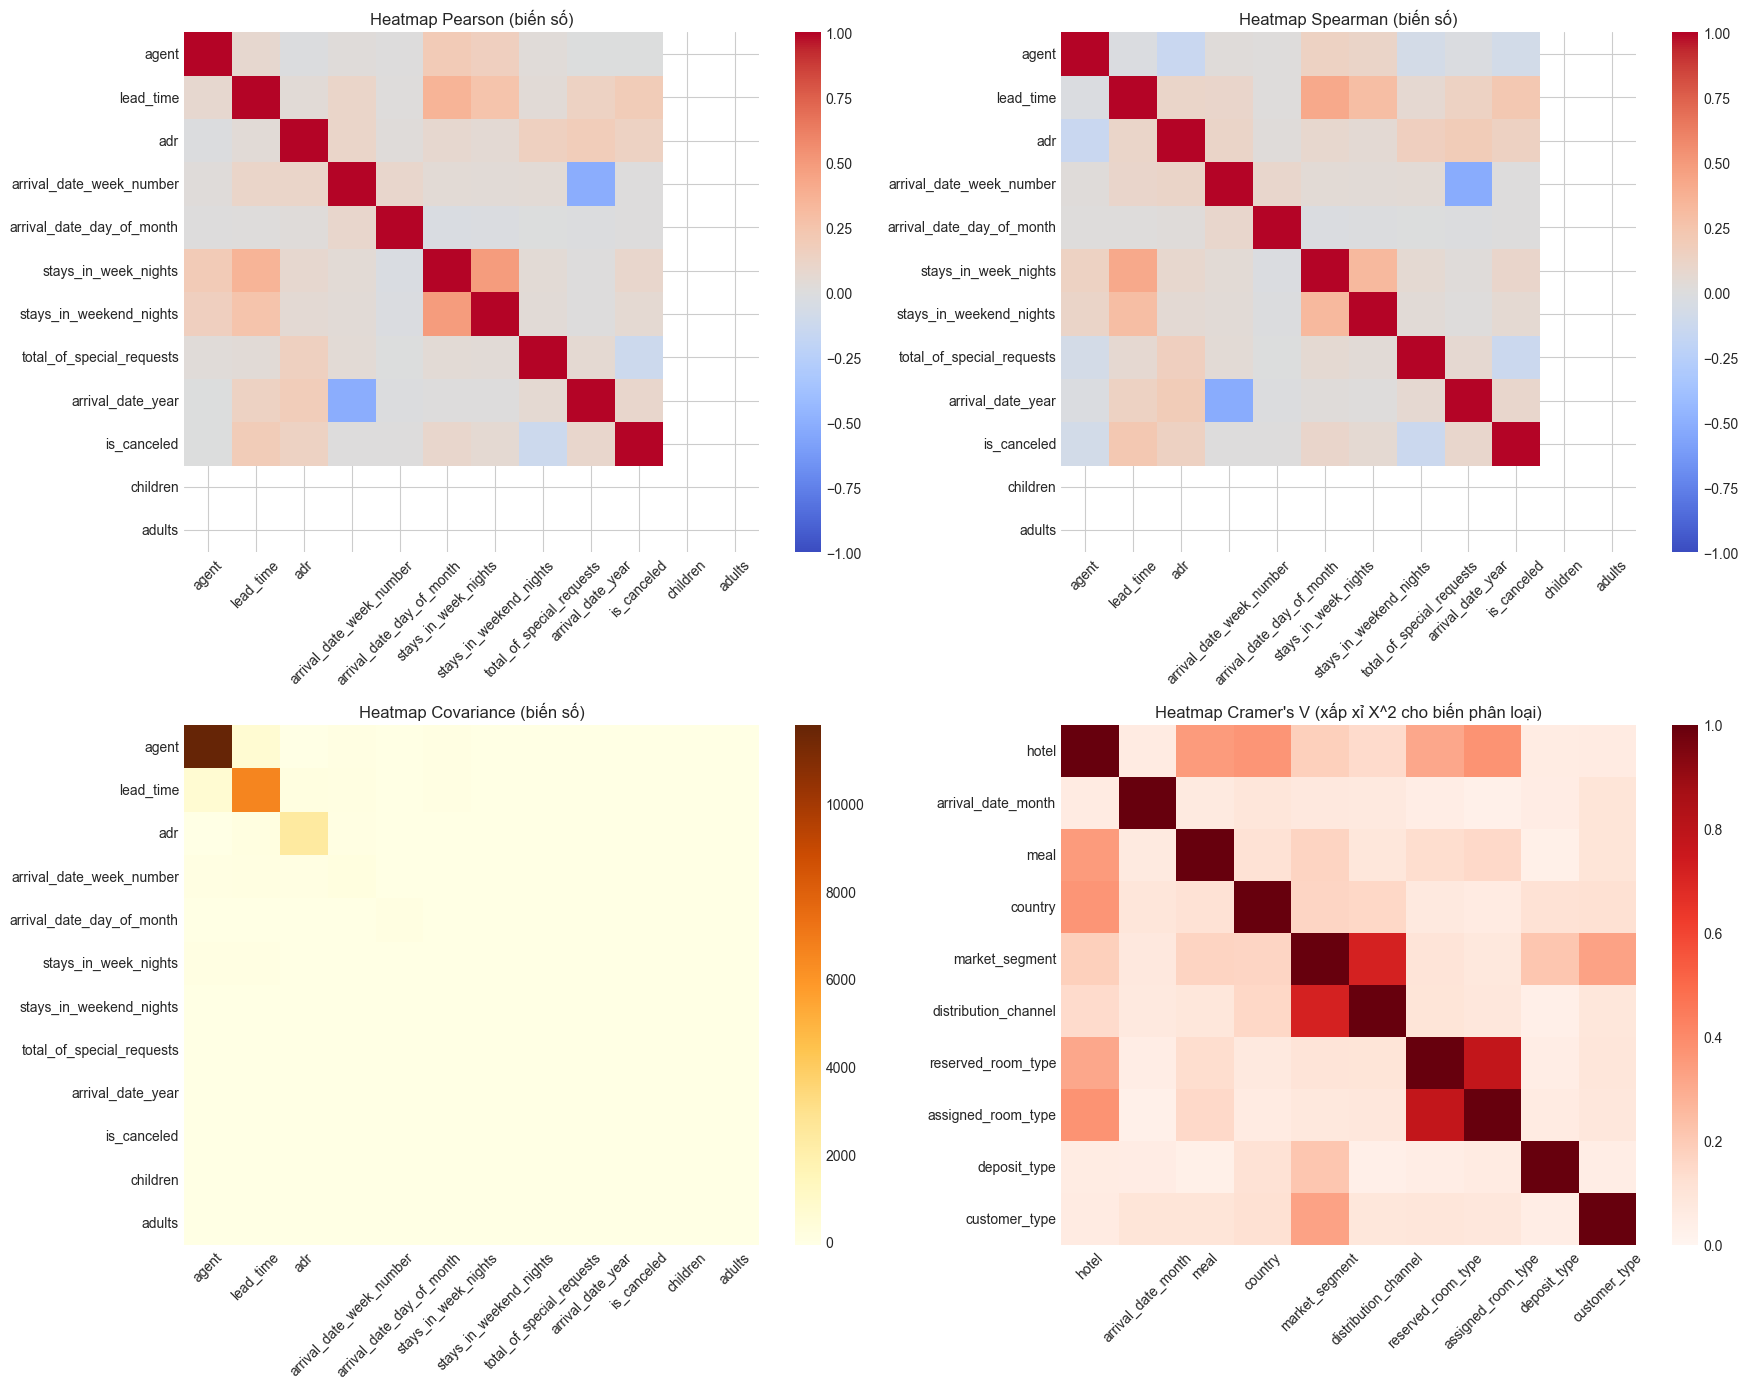

Cặp thuộc tính tương quan cao được chọn: ('arrival_date_month', 'reservation_status_date')
Theo thước đo: Chi-square = 572225.3443, p-value = 0


In [17]:
from itertools import combinations

num_cols_corr = df_denoised.select_dtypes(include=[np.number]).columns.tolist()
cat_cols_corr = df_denoised.select_dtypes(exclude=[np.number]).columns.tolist()

pearson_records = []
spearman_records = []
cov_records = []

for a, b in combinations(num_cols_corr, 2):
    pair = df_denoised[[a, b]].dropna()
    if len(pair) < 3:
        continue
    pearson_val = pair[a].corr(pair[b], method="pearson")
    spearman_val = pair[a].corr(pair[b], method="spearman")
    cov_val = pair[a].cov(pair[b])
    pearson_records.append((a, b, pearson_val, abs(pearson_val)))
    spearman_records.append((a, b, spearman_val, abs(spearman_val)))
    cov_records.append((a, b, cov_val, abs(cov_val)))

chi2_records = []
for a, b in combinations(cat_cols_corr, 2):
    table = pd.crosstab(df_denoised[a], df_denoised[b])
    if table.shape[0] < 2 or table.shape[1] < 2:
        continue
    chi2_stat, p_value, _, _ = chi2_contingency(table)
    chi2_records.append((a, b, chi2_stat, p_value))

pearson_df = pd.DataFrame(pearson_records, columns=["attr_1", "attr_2", "pearson", "abs_pearson"])
spearman_df = pd.DataFrame(spearman_records, columns=["attr_1", "attr_2", "spearman", "abs_spearman"])
cov_df = pd.DataFrame(cov_records, columns=["attr_1", "attr_2", "covariance", "abs_covariance"])
chi2_df = pd.DataFrame(chi2_records, columns=["attr_1", "attr_2", "chi2", "p_value"])

display(pearson_df.sort_values("abs_pearson", ascending=False).head(10))
display(spearman_df.sort_values("abs_spearman", ascending=False).head(10))
display(cov_df.sort_values("abs_covariance", ascending=False).head(10))
display(chi2_df.sort_values("chi2", ascending=False).head(10))

# Vẽ trực quan tương quan theo 4 thước đo (bar chart)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

pearson_top = pearson_df.sort_values("abs_pearson", ascending=False).head(10).copy()
pearson_top["pair"] = pearson_top["attr_1"] + " - " + pearson_top["attr_2"]
sns.barplot(data=pearson_top, x="abs_pearson", y="pair", ax=axes[0, 0], color="#1f77b4")
axes[0, 0].set_title("Top 10 |Pearson|")
axes[0, 0].set_xlabel("|Pearson correlation|")
axes[0, 0].set_ylabel("Cặp thuộc tính")

spearman_top = spearman_df.sort_values("abs_spearman", ascending=False).head(10).copy()
spearman_top["pair"] = spearman_top["attr_1"] + " - " + spearman_top["attr_2"]
sns.barplot(data=spearman_top, x="abs_spearman", y="pair", ax=axes[0, 1], color="#2ca02c")
axes[0, 1].set_title("Top 10 |Spearman|")
axes[0, 1].set_xlabel("|Spearman correlation|")
axes[0, 1].set_ylabel("Cặp thuộc tính")

cov_top = cov_df.sort_values("abs_covariance", ascending=False).head(10).copy()
cov_top["pair"] = cov_top["attr_1"] + " - " + cov_top["attr_2"]
sns.barplot(data=cov_top, x="abs_covariance", y="pair", ax=axes[1, 0], color="#ff7f0e")
axes[1, 0].set_title("Top 10 |Covariance|")
axes[1, 0].set_xlabel("|Covariance|")
axes[1, 0].set_ylabel("Cặp thuộc tính")

chi2_top = chi2_df.sort_values("chi2", ascending=False).head(10).copy()
chi2_top["pair"] = chi2_top["attr_1"] + " - " + chi2_top["attr_2"]
sns.barplot(data=chi2_top, x="chi2", y="pair", ax=axes[1, 1], color="#d62728")
axes[1, 1].set_title("Top 10 Chi-square (X^2)")
axes[1, 1].set_xlabel("Chi-square statistic")
axes[1, 1].set_ylabel("Cặp thuộc tính")

plt.tight_layout()
plt.show()

# Vẽ heatmap cho câu 8
num_limit = min(12, len(num_cols_corr))
selected_num = (
    df_denoised[num_cols_corr]
    .std(numeric_only=True)
    .sort_values(ascending=False)
    .head(num_limit)
    .index.tolist()
)

pearson_mat = df_denoised[selected_num].corr(method="pearson")
spearman_mat = df_denoised[selected_num].corr(method="spearman")
cov_mat = df_denoised[selected_num].cov()

cat_limit = min(10, len(cat_cols_corr))
selected_cat = cat_cols_corr[:cat_limit]
cramers_v_mat = pd.DataFrame(
    np.eye(len(selected_cat)),
    index=selected_cat,
    columns=selected_cat,
    dtype=float,
)

for i, a in enumerate(selected_cat):
    for j, b in enumerate(selected_cat):
        if i >= j:
            continue
        table = pd.crosstab(df_denoised[a], df_denoised[b])
        if table.shape[0] < 2 or table.shape[1] < 2:
            v = 0.0
        else:
            chi2_stat, _, _, _ = chi2_contingency(table)
            n = table.values.sum()
            if n == 0:
                v = 0.0
            else:
                phi2 = chi2_stat / n
                r, k = table.shape
                denom = max(1, min(k - 1, r - 1))
                v = float(np.sqrt(phi2 / denom))
        cramers_v_mat.loc[a, b] = v
        cramers_v_mat.loc[b, a] = v

fig, axes = plt.subplots(2, 2, figsize=(18, 14))

sns.heatmap(pearson_mat, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0, 0])
axes[0, 0].set_title("Heatmap Pearson (biến số)")

sns.heatmap(spearman_mat, cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0, 1])
axes[0, 1].set_title("Heatmap Spearman (biến số)")

sns.heatmap(cov_mat, cmap="YlOrBr", ax=axes[1, 0])
axes[1, 0].set_title("Heatmap Covariance (biến số)")

sns.heatmap(cramers_v_mat, cmap="Reds", vmin=0, vmax=1, ax=axes[1, 1])
axes[1, 1].set_title("Heatmap Cramer's V (xấp xỉ X^2 cho biến phân loại)")

for ax in axes.ravel():
    ax.tick_params(axis="x", rotation=45)
    ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

top_pair = None
top_score = -np.inf
top_method = None

if not pearson_df.empty:
    row = pearson_df.sort_values("abs_pearson", ascending=False).iloc[0]
    if row["abs_pearson"] > top_score:
        top_score = float(row["abs_pearson"])
        top_pair = (row["attr_1"], row["attr_2"])
        top_method = f"Pearson = {row['pearson']:.4f}"

if not spearman_df.empty:
    row = spearman_df.sort_values("abs_spearman", ascending=False).iloc[0]
    if row["abs_spearman"] > top_score:
        top_score = float(row["abs_spearman"])
        top_pair = (row["attr_1"], row["attr_2"])
        top_method = f"Spearman = {row['spearman']:.4f}"

if not chi2_df.empty:
    # Chuẩn hóa tương đối theo max chi2 để so sánh nội bộ trong báo cáo
    chi2_max = float(chi2_df["chi2"].max())
    row = chi2_df.sort_values("chi2", ascending=False).iloc[0]
    if chi2_max > 0 and 1.0 > top_score:
        top_pair = (row["attr_1"], row["attr_2"])
        top_method = f"Chi-square = {row['chi2']:.4f}, p-value = {row['p_value']:.4g}"

if top_pair is not None:
    print("Cặp thuộc tính tương quan cao được chọn:", top_pair)
    print("Theo thước đo:", top_method)
else:
    print("Không đủ dữ liệu để xác định cặp tương quan cao nhất.")

## Giải thích cặp tương quan cao nhất (kết quả thực nghiệm)

Dựa trên kết quả đã chạy ở phần 8, cặp thuộc tính có mức liên hệ mạnh nhất là:

- **`arrival_date_month`** và **`reservation_status_date`**
- Theo kiểm định **Chi-square (X²)**: $\chi^2 = 572225.3443$
- **p-value = 0** (xấp xỉ rất nhỏ, gần 0)

### Diễn giải thống kê

- Giá trị $\chi^2$ rất lớn cho thấy phân phối của `reservation_status_date` thay đổi mạnh theo `arrival_date_month`.
- p-value gần 0 cho thấy bác bỏ giả thuyết độc lập giữa hai biến ở mức ý nghĩa thông dụng (ví dụ 5%).
- Kết luận: hai biến phân loại này **có quan hệ phụ thuộc thống kê rất mạnh** trong bộ dữ liệu.

### Diễn giải nghiệp vụ

- Theo bối cảnh khách sạn, tính mùa vụ theo tháng đến (`arrival_date_month`) ảnh hưởng rõ rệt đến trạng thái đặt phòng theo thời gian (`reservation_status_date`).
- Vào các tháng cao điểm/thấp điểm, hành vi đặt - hủy - xác nhận phòng thường khác nhau, làm phân phối ngày trạng thái đặt phòng thay đổi tương ứng.